# Looking at the Iris dataset with a GAN and a copula
The iris dataset is a common dataset that only has 150 rows. We can see that this is not sufficient for a GAN, but we can see that we can use a copula to do a decent job of it

In [1]:
# import libraries needed
import numpy as np
from sklearn.datasets import load_iris
from copulae.elliptical.student import StudentCopula
from scipy.stats import rankdata
from sklearn.decomposition import PCA
import torch
import matplotlib.pyplot as plt
from gan.models import Generator, Discriminator
from gan.training import train_gan


In [2]:

# Load data
iris = load_iris()
X = iris.data.astype(float)


#### First training a GAN on the data

In [3]:
# set a seed for reproducibility
torch.manual_seed(42)
# first get instances of the model
G = Generator(
    noise_dim=2,
    hidden_dims=(128,128),
    num_hidden_layers=2,
    out_dim=4
)

D = Discriminator(
    feature_dim=4,
    hidden_dims=(128,128),
    num_hidden_layers=2
)

In [ ]:
# train the GAN
train_gan(
    X=torch.tensor(X).float(),
    G=G,
    D=D,
    return_history=False
)

GAN training:   0%|          | 0/200 [00:00<?, ?it/s]

In [5]:
# generate synthetic data from the GAN
X_synth_gan = G.generate(500).detach().cpu().numpy()

#### Now fitting a copula to the data

In [6]:

# Convert to Uniform(0,1) using ranks
U = np.zeros_like(X)
for j in range(X.shape[1]):
    U[:, j] = rankdata(X[:, j]) / (len(X) + 1)

# Fit Student t‑copula
cop = StudentCopula(dim=X.shape[1], df=4.0)  # initial df, will be updated
cop.fit(U)

# Sample synthetic uniform samples
n_samples = 500
U_synth = cop.random(n_samples)

# Map back to original scale using empirical inverse CDF
X_synth = np.zeros_like(U_synth)
for j in range(X.shape[1]):
    sorted_vals = np.sort(X[:, j])
    idx = (U_synth[:, j] * len(sorted_vals)).astype(int)
    idx = np.clip(idx, 0, len(sorted_vals)-1)
    X_synth[:, j] = sorted_vals[idx]


#### Now we compare the results from fitting a GAN and fitting a copula

Original correlations:
 [[ 1.    -0.118  0.872  0.818]
 [-0.118  1.    -0.428 -0.366]
 [ 0.872 -0.428  1.     0.963]
 [ 0.818 -0.366  0.963  1.   ]]
Synthetic (t‑copula) corr:
 [[ 1.    -0.15   0.837  0.778]
 [-0.15   1.    -0.259 -0.23 ]
 [ 0.837 -0.259  1.     0.818]
 [ 0.778 -0.23   0.818  1.   ]]
Synthetic (GAN) corr:
  [[ 1.     0.913  0.575  0.088]
 [ 0.913  1.     0.194 -0.323]
 [ 0.575  0.194  1.     0.863]
 [ 0.088 -0.323  0.863  1.   ]]


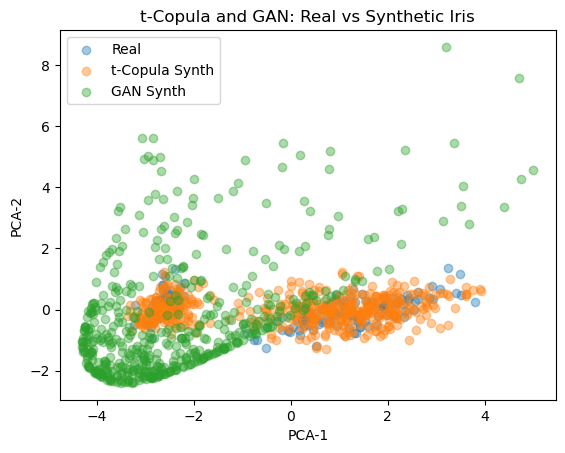

In [7]:

# Correlation diagnostics
print("Original correlations:\n", np.round(np.corrcoef(X.T), 3))
print("Synthetic (t‑copula) corr:\n", np.round(np.corrcoef(X_synth.T), 3))
print("Synthetic (GAN) corr:\n ",np.round(np.corrcoef(X_synth_gan.T), 3))

# Optional PCA scatter
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
X_synth_pca = pca.transform(X_synth)
X_synth_pca_gan = pca.transform(X_synth_gan)

plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.4, label="Real")
plt.scatter(X_synth_pca[:,0], X_synth_pca[:,1], alpha=0.4, label="t‑Copula Synth")
plt.scatter(X_synth_pca_gan[:,0],X_synth_pca_gan[:,1], alpha=0.4, label="GAN Synth")
plt.legend()
plt.xlabel("PCA-1")
plt.ylabel("PCA-2")
plt.title("t‑Copula and GAN: Real vs Synthetic Iris")
plt.show()



### Conclusions
We see that the GAN failed to give a reasonable generation of data. The matrix of correlations with the GAN is nothing like the original, and when we project on to the first two PCA dimensions we see nothing like the distribution of the original data. The copula preserves the signs of the correlation and has similar correlations to the original data, and plotting in the first two PCA coordinates we see that the synthetic data from the copula looks similar to the original real data